# 0. Import Libraries

In [1]:
import os, sys
from pathlib import Path

def add_project_path(module_folder="model_implementation"):
    candidates = [
        os.path.abspath("."),
        os.path.abspath("../src"),
        os.path.abspath("src"),
    ]

    for path in candidates:
        if os.path.exists(os.path.join(path, module_folder)):
            if path not in sys.path:
                sys.path.append(path)
            return path

    raise ImportError(f"Could not find '{module_folder}' in current or parent directory")

SRC_PATH = add_project_path("model_implementation")
add_project_path("cnn")
add_project_path("rnn")
ROOT = Path(SRC_PATH).parent.resolve()
print("ROOT:", ROOT)

ROOT: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [2]:
from pathlib import Path
from datetime import datetime
import gc
import itertools
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
except Exception as exc:
    tf = None
    layers = models = None
    print("TensorFlow belum tersedia:", exc)

try:
    from sklearn.metrics import f1_score
    from sklearn.model_selection import train_test_split
except Exception as exc:
    f1_score = None
    train_test_split = None
    print("scikit-learn belum tersedia:", exc)

from cnn.layers import Conv2D, LocallyConnected2D, MaxPooling2D, AveragePooling2D, GlobalMaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Sequential
from cnn.utility import image_loader, batch_loader, image_paths, feature_extractor
from common.io import save_json, load_json, load_npy, save_npy
from rnn.preprocess import read_captions, prep_data, load_vocab
from rnn.sequences import align_features_to_captions, teacher_pairs
from rnn.keras_models import build_preinject, compile_model
from rnn.train import grid_cfg
from rnn.weights import export_weights
from rnn.decode import decode_batch
from rnn.caption_decoder import build_decoder
from rnn.evaluate import eval_keras as eval_caption_keras, eval_caption_decoder, hist_sum, seq_tokens
from common.metrics import bleu4_score, meteor_safe

# 1. Global Variables

In [3]:
SEED = 42
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 10
MAX_CAPTION_LENGTH = 34

np.random.seed(SEED)
plt.style.use("seaborn-v0_8")

DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
FEATURE_DIR = DATA_DIR / "features"
VOCAB_DIR = DATA_DIR / "vocab"
MODEL_DIR = ROOT / "models"
CNN_MODEL_DIR = MODEL_DIR / "cnn"
RNN_MODEL_DIR = MODEL_DIR / "rnn"
REPORT_DIR = ROOT / "reports"
TABLE_DIR = REPORT_DIR / "tables"
FIG_DIR = REPORT_DIR / "figures"

for path in [FEATURE_DIR, VOCAB_DIR, CNN_MODEL_DIR, RNN_MODEL_DIR, TABLE_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

CATEGORIES = {
    "buildings": 0,
    "forest": 1,
    "glacier": 2,
    "mountain": 3,
    "sea": 4,
    "street": 5,
}
INV_CATEGORIES = {v: k for k, v in CATEGORIES.items()}

if tf is not None:
    gpu_devices = tf.config.list_physical_devices("GPU")
    if gpu_devices:
        print("GPU Detected:", gpu_devices)
        for gpu in gpu_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
    else:
        print("No GPU found, defaulting to CPU.")

No GPU found, defaulting to CPU.


# 2. Loading Intel Image Classification Data

In [4]:
def load_intel_dataset(root_path, target_size=(150, 150)):
    X, y = [], []
    root = Path(root_path)
    for category, label in CATEGORIES.items():
        cat_path = root / category
        if not cat_path.exists():
            continue
        print(f"Loading {category}...")
        for image_path in image_paths(cat_path):
            try:
                X.append(image_loader(image_path, target_size=target_size))
                y.append(label)
            except Exception as exc:
                print(f"Error loading {image_path}: {exc}")
    return np.asarray(X, dtype="float32"), np.asarray(y, dtype="int32")

def first_existing_path(candidates):
    for path in candidates:
        if Path(path).exists():
            return Path(path)
    return Path(candidates[0])

TRAIN_DIR = first_existing_path([
    RAW_DIR / "intel" / "seg_train",
    RAW_DIR / "intel" / "seg_train" / "seg_train",
    RAW_DIR / "intel_image_classification" / "seg_train",
    RAW_DIR / "intel_image_classification" / "seg_train" / "seg_train",
    ROOT / "seg_train" / "seg_train",
])
TEST_DIR = first_existing_path([
    RAW_DIR / "intel" / "seg_test",
    RAW_DIR / "intel" / "seg_test" / "seg_test",
    RAW_DIR / "intel_image_classification" / "seg_test",
    RAW_DIR / "intel_image_classification" / "seg_test" / "seg_test",
    ROOT / "seg_test" / "seg_test",
])

X_train = X_val = X_test = y_train = y_val = y_test = None

if TRAIN_DIR.exists() and TEST_DIR.exists() and train_test_split is not None:
    print("--- Loading Training Data ---")
    print("TRAIN_DIR:", TRAIN_DIR)
    X_all, y_all = load_intel_dataset(TRAIN_DIR, target_size=IMAGE_SIZE)
    print("--- Loading Test Data ---")
    print("TEST_DIR:", TEST_DIR)
    X_test, y_test = load_intel_dataset(TEST_DIR, target_size=IMAGE_SIZE)
    X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
    print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
else:
    print("Dataset Intel belum tersedia atau scikit-learn belum siap. CNN cells akan dilewati.")

--- Loading Training Data ---
TRAIN_DIR: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/data/raw/intel/seg_train
Loading buildings...
Loading forest...
Loading glacier...
Loading mountain...
Loading sea...
Loading street...
--- Loading Test Data ---
TEST_DIR: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/data/raw/intel/seg_test
Loading buildings...
Loading forest...
Loading glacier...
Loading mountain...
Loading sea...
Loading street...
Train: (11227, 150, 150, 3) Val: (2807, 150, 150, 3) Test: (3000, 150, 150, 3)


# 3. CNN Keras Training

/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> Loading CNN Experiment 1/16 from saved artifacts.


/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> Loading CNN Experiment 2/16 from saved artifacts.


/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...


>>> Loading CNN Experiment 14/16 from saved artifacts.


/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> Loading CNN Experiment 15/16 from saved artifacts.


/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> Loading CNN Experiment 16/16 from saved artifacts.


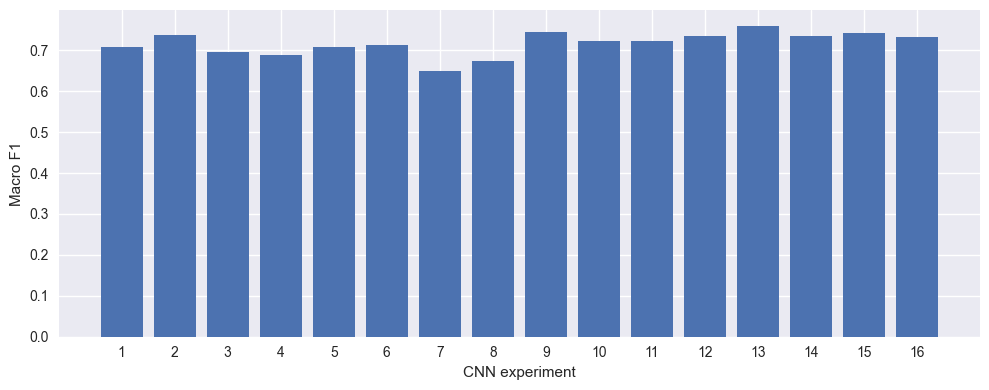


[SUCCESS] CNN Keras artifacts ready in: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/models/cnn


,index,experiment_id,num_layers,filters,kernel_size,pooling_type,macro_f1,model_path,keras_weight_path,history_path,shared_parameters
0,1,0,2,32,3,max,0.707264,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
1,2,1,2,32,3,avg,0.737065,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
2,3,2,2,32,5,max,0.695736,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
3,4,3,2,32,5,avg,0.688956,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
4,5,4,2,64,3,max,0.708734,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
5,6,5,2,64,3,avg,0.712394,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
6,7,6,2,64,5,max,0.649224,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
7,8,7,2,64,5,avg,0.673683,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
8,9,8,3,32,3,max,0.743906,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
9,10,9,3,32,3,avg,0.722801,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True


In [5]:
import pickle

# CNN pipeline mirrors notebooks/intel_image_classification.ipynb.
# It can resume from saved .npy weights/.pkl histories, so main stays safe to rerun.
def prepare_dataset_safe(X, y, batch_size=32, shuffle=False):
    def get_generator():
        for i in range(len(X)):
            yield X[i], y[i]

    dataset = tf.data.Dataset.from_generator(
        get_generator,
        output_signature=(
            tf.TensorSpec(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int64),
        ),
    )
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(500, len(X)), seed=SEED, reshuffle_each_iteration=True)
    return dataset.batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE)

def build_keras_cnn(config):
    model = models.Sequential(name=f"Keras_Architecture_{config['num_layers']}_{config['filters']}_{config['kernel_size']}_{config['pooling_type']}")
    model.add(layers.Conv2D(
        config['filters'],
        (config['kernel_size'], config['kernel_size']),
        activation='relu',
        padding='same',
        input_shape=(*IMAGE_SIZE, 3),
    ))

    for _ in range(config['num_layers'] - 1):
        model.add(layers.Conv2D(
            config['filters'],
            (config['kernel_size'], config['kernel_size']),
            activation='relu',
            padding='same',
        ))
        if config['pooling_type'] == 'max':
            model.add(layers.MaxPooling2D((2, 2)))
        else:
            model.add(layers.AveragePooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(len(CATEGORIES), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def save_keras_weight_dict(model, path):
    weight_dict = {}
    for layer in model.layers:
        weights = layer.get_weights()
        if weights:
            weight_dict[layer.name] = weights
    np.save(path, weight_dict)

def load_weight_dict_into_model(model, weight_path):
    weights_dict = np.load(weight_path, allow_pickle=True).item()
    trainable_layers = [layer for layer in model.layers if layer.get_weights()]
    for layer, (_, layer_weights) in zip(trainable_layers, weights_dict.items()):
        layer.set_weights(layer_weights)
    return model, weights_dict

cnn_results_registry = []
cnn_histories = []
keras_experiments_configs = []

if tf is not None and X_train is not None:
    train_steps = int(np.ceil(len(X_train) / BATCH_SIZE))
    val_steps = int(np.ceil(len(X_val) / BATCH_SIZE))
    test_steps = int(np.ceil(len(X_test) / BATCH_SIZE)) if X_test is not None else 0

    train_ds = prepare_dataset_safe(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
    val_ds = prepare_dataset_safe(X_val, y_val, batch_size=BATCH_SIZE)
    test_ds = prepare_dataset_safe(X_test, y_test, batch_size=BATCH_SIZE) if X_test is not None else None

    keras_variations = {
        'num_layers': [2, 3],
        'filters': [32, 64],
        'kernel_size': [3, 5],
        'pooling_type': ['max', 'avg'],
    }
    keys, values = zip(*keras_variations.items())
    keras_experiments_configs = [dict(zip(keys, item)) for item in itertools.product(*values)]

    for idx, cfg in enumerate(keras_experiments_configs):
        experiment_index = idx + 1
        history_path = CNN_MODEL_DIR / f'history_exp_{idx}.pkl'
        npy_weight_path = CNN_MODEL_DIR / f'keras_weights_exp_{idx}.npy'
        model_path = CNN_MODEL_DIR / f'cnn_exp_{experiment_index:02d}.keras'

        tf.keras.backend.clear_session()
        model = build_keras_cnn(cfg)

        if history_path.exists() and npy_weight_path.exists():
            print(f"\n>>> Loading CNN Experiment {experiment_index}/16 from saved artifacts.")
            model, _ = load_weight_dict_into_model(model, npy_weight_path)
            with open(history_path, 'rb') as f:
                history_data = pickle.load(f)
        else:
            print(f"\n--- Running CNN Keras Experiment {experiment_index}/16: {cfg} ---")
            history = model.fit(
                train_ds,
                epochs=EPOCHS,
                steps_per_epoch=train_steps,
                validation_data=val_ds,
                validation_steps=val_steps,
                verbose=1,
            )
            history_data = history.history
            model.save(model_path)
            save_keras_weight_dict(model, npy_weight_path)
            with open(history_path, 'wb') as f:
                pickle.dump(history_data, f)

        if test_ds is not None:
            y_pred = np.argmax(model.predict(test_ds, steps=test_steps, verbose=0), axis=1)[:len(y_test)]
            macro_f1 = float(f1_score(y_test, y_pred, average='macro')) if f1_score is not None else None
        else:
            macro_f1 = None

        record = {
            'index': experiment_index,
            'experiment_id': idx,
            **cfg,
            'macro_f1': macro_f1,
            'model_path': str(model_path),
            'keras_weight_path': str(npy_weight_path),
            'history_path': str(history_path),
            'shared_parameters': True,
        }
        cnn_results_registry.append(record)
        cnn_histories.append({'index': experiment_index, 'config': cfg, 'history': history_data})
        del model
        gc.collect()

    save_json(cnn_results_registry, TABLE_DIR / 'cnn_records.json')
    save_json(cnn_histories, TABLE_DIR / 'cnn_histories.json')

    cnn_df = pd.DataFrame(cnn_results_registry)
    cnn_df.to_csv(TABLE_DIR / 'cnn_records.csv', index=False)
    cnn_df.to_csv(CNN_MODEL_DIR / 'keras_experiment_summary.csv', index=False)

    if not cnn_df.empty and 'macro_f1' in cnn_df:
        factor_tables = {
            'cnn_by_num_layers.csv': cnn_df.groupby('num_layers', as_index=False)['macro_f1'].mean(),
            'cnn_by_filters.csv': cnn_df.groupby('filters', as_index=False)['macro_f1'].mean(),
            'cnn_by_kernel_size.csv': cnn_df.groupby('kernel_size', as_index=False)['macro_f1'].mean(),
            'cnn_by_pooling_type.csv': cnn_df.groupby('pooling_type', as_index=False)['macro_f1'].mean(),
        }
        for filename, table in factor_tables.items():
            table.to_csv(TABLE_DIR / filename, index=False)

        plt.figure(figsize=(10, 4))
        plt.bar(cnn_df['index'].astype(str), cnn_df['macro_f1'].fillna(0.0))
        plt.xlabel('CNN experiment')
        plt.ylabel('Macro F1')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'cnn_macro_f1.png', dpi=160)
        plt.show()

    print(f"\n[SUCCESS] CNN Keras artifacts ready in: {CNN_MODEL_DIR}")
else:
    print("CNN training dilewati.")

pd.DataFrame(cnn_results_registry)


# 4. CNN Forward Propagation

In [6]:
from model_implementation.layer.activation import relu, softmax
from common.autograd import Value
import importlib
import time

import cnn.layers as cnn_layers
cnn_layers = importlib.reload(cnn_layers)
Conv2D = cnn_layers.Conv2D
LocallyConnected2D = cnn_layers.LocallyConnected2D
MaxPooling2D = cnn_layers.MaxPooling2D
AveragePooling2D = cnn_layers.AveragePooling2D
Flatten = cnn_layers.Flatten

class RecursiveLearnaholicCNN:
    def __init__(self, cfg, weights_dict, shared_parameter=True):
        self.layers = []
        self.shared_parameter = shared_parameter
        self.cfg = cfg
        self.relu_act = relu()
        self.softmax_act = softmax()
        self.final_activation = self.softmax_act

        weight_keys = [key for key in weights_dict.keys() if 'conv2d' in key or 'dense' in key]
        current_h, current_w = IMAGE_SIZE
        in_channels = 3

        for l_idx in range(cfg['num_layers']):
            k_w, k_b = weights_dict[weight_keys[l_idx]]
            pad = cfg['kernel_size'] // 2

            if self.shared_parameter:
                layer = Conv2D(in_channels, cfg['filters'], cfg['kernel_size'], padding=pad)
                layer.weight, layer.bias = k_w, k_b
            else:
                layer = LocallyConnected2D(in_channels, cfg['filters'], (current_h, current_w), cfg['kernel_size'], padding=pad)
                flattened_weight = k_w.reshape(-1, cfg['filters'])
                layer.weight = np.tile(flattened_weight, (current_h * current_w, 1, 1))
                layer.bias = np.tile(k_b, (current_h, current_w, 1))

            self.layers.append(layer)
            self.layers.append(self.relu_act)

            # Match Keras exactly: first Conv2D has no pooling; each additional Conv2D is followed by pooling.
            if l_idx > 0:
                if cfg['pooling_type'] == 'max':
                    self.layers.append(MaxPooling2D())
                else:
                    self.layers.append(AveragePooling2D())
                current_h //= 2
                current_w //= 2

            in_channels = cfg['filters']

        self.layers.append(Flatten())
        self.dense_w, self.dense_b = weights_dict[weight_keys[-1]]

    def forward(self, x):
        out = x
        for layer in self.layers:
            if isinstance(out, Value):
                out = out.data
            out = layer.forward(out)

        if isinstance(out, Value):
            out = out.data

        logits = (out @ self.dense_w) + self.dense_b
        return self.final_activation.forward(logits)

    def count_params(self):
        total = 0
        for layer in self.layers:
            if hasattr(layer, 'weight') and layer.weight is not None:
                total += layer.weight.size + layer.bias.size
        total += self.dense_w.size + self.dense_b.size
        return int(total)

def balanced_sample_indices(y, total=96):
    rng = np.random.default_rng(SEED)
    labels = sorted(np.unique(y))
    per_class = max(1, total // len(labels))
    indices = []
    for label in labels:
        candidates = np.flatnonzero(y == label)
        take = min(per_class, len(candidates))
        indices.extend(rng.choice(candidates, size=take, replace=False))
    return np.asarray(indices, dtype=int)

cnn_manual_comparison = []
cnn_layer_checks = []
local_cnn_record = None

if cnn_results_registry and X_test is not None and tf is not None:
    best = max(cnn_results_registry, key=lambda item: item.get('macro_f1') or 0.0)
    best_cfg = {key: best[key] for key in ['num_layers', 'filters', 'kernel_size', 'pooling_type']}
    best_model = build_keras_cnn(best_cfg)
    best_model, best_weights = load_weight_dict_into_model(best_model, best['keras_weight_path'])

    model_shared = RecursiveLearnaholicCNN(best_cfg, best_weights, shared_parameter=True)
    model_non_shared = RecursiveLearnaholicCNN(best_cfg, best_weights, shared_parameter=False)

    # Diagnostic: every shared scratch layer should match Keras before comparing scores.
    diag_x = X_test[:min(24, len(X_test))]
    keras_out = diag_x
    scratch_out = diag_x
    keras_layer_index = 0
    for scratch_layer in model_shared.layers:
        if isinstance(scratch_out, Value):
            scratch_out = scratch_out.data

        if isinstance(scratch_layer, (Conv2D, MaxPooling2D, AveragePooling2D, Flatten)):
            scratch_out = scratch_layer.forward(scratch_out)
        else:
            scratch_out = scratch_layer.forward(scratch_out)
            if isinstance(scratch_out, Value):
                scratch_out = scratch_out.data

        keras_layer = best_model.layers[keras_layer_index]
        keras_name = keras_layer.__class__.__name__
        if keras_name == 'Conv2D' and isinstance(scratch_layer, Conv2D):
            keras_out = keras_layer(keras_out).numpy()
            scratch_compare = np.maximum(0, scratch_out)
        elif keras_name in ('MaxPooling2D', 'AveragePooling2D') and isinstance(scratch_layer, (MaxPooling2D, AveragePooling2D)):
            keras_out = keras_layer(keras_out).numpy()
            scratch_compare = scratch_out
        elif keras_name == 'Flatten' and isinstance(scratch_layer, Flatten):
            keras_out = keras_layer(keras_out).numpy()
            scratch_compare = scratch_out
        else:
            continue

        max_abs_diff = float(np.max(np.abs(keras_out - scratch_compare)))
        cnn_layer_checks.append({
            'layer_index': keras_layer_index,
            'layer': keras_name,
            'max_abs_diff': max_abs_diff,
            'match': bool(np.allclose(keras_out, scratch_compare, atol=1e-5)),
        })
        keras_layer_index += 1

    sample_idx = balanced_sample_indices(y_test, total=96)
    sample_x = X_test[sample_idx]
    sample_y = y_test[sample_idx]

    start_k = time.time()
    keras_raw = best_model.predict(sample_x, verbose=0)
    keras_time = time.time() - start_k
    keras_pred = np.argmax(keras_raw, axis=1)

    start_s = time.time()
    scratch_shared_raw = model_shared.forward(sample_x)
    if isinstance(scratch_shared_raw, Value):
        scratch_shared_raw = scratch_shared_raw.data
    scratch_time = time.time() - start_s
    scratch_pred = np.argmax(scratch_shared_raw, axis=1)

    small_batch = X_test[:min(5, len(X_test))]
    small_y = y_test[:len(small_batch)]
    scratch_ns_raw = model_non_shared.forward(small_batch)
    if isinstance(scratch_ns_raw, Value):
        scratch_ns_raw = scratch_ns_raw.data
    scratch_ns_pred = np.argmax(scratch_ns_raw, axis=1)

    p_shared = model_shared.count_params()
    p_non_shared = model_non_shared.count_params()
    local_cnn_record = {
        'implementation': 'scratch_numpy_non_shared',
        'config': best_cfg,
        'macro_f1_small_batch': float(f1_score(small_y, scratch_ns_pred, average='macro')) if f1_score is not None else None,
        'params': p_non_shared,
        'shared_params': p_shared,
        'parameter_explosion': float(p_non_shared / p_shared),
        'shared_parameters': False,
    }

    cnn_manual_comparison = [
        {
            'implementation': 'keras_shared',
            'macro_f1': float(f1_score(sample_y, keras_pred, average='macro')),
            'runtime_seconds': float(keras_time),
            'params': int(best_model.count_params()),
            'numerical_match': True,
        },
        {
            'implementation': 'scratch_numpy_shared',
            'macro_f1': float(f1_score(sample_y, scratch_pred, average='macro')),
            'runtime_seconds': float(scratch_time),
            'params': p_shared,
            'numerical_match': bool(np.allclose(keras_raw, scratch_shared_raw, atol=1e-5)),
        },
        local_cnn_record,
    ]

    save_json(cnn_manual_comparison, TABLE_DIR / 'cnn_manual_comparison.json')
    save_json(cnn_layer_checks, TABLE_DIR / 'cnn_layer_checks.json')
    save_json(local_cnn_record, TABLE_DIR / 'cnn_local_record.json')
    pd.DataFrame(cnn_manual_comparison).to_csv(TABLE_DIR / 'cnn_manual_comparison.csv', index=False)
    pd.DataFrame(cnn_layer_checks).to_csv(TABLE_DIR / 'cnn_layer_checks.csv', index=False)

    print('Best CNN config:', best_cfg)
    print('Layer checks all match:', all(row['match'] for row in cnn_layer_checks))
    print('Keras vs scratch numerical match:', cnn_manual_comparison[1]['numerical_match'])
    print('Shared params:', f'{p_shared:,}')
    print('Non-shared params:', f'{p_non_shared:,}')
else:
    print("CNN scratch comparison dilewati.")

cnn_manual_comparison


/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best CNN config: {'num_layers': 3, 'filters': 64, 'kernel_size': 3, 'pooling_type': 'max'}
Layer checks all match: True
Keras vs scratch numerical match: True
Shared params: 601,350
Non-shared params: 1,079,445,702


[{'implementation': 'keras_shared',
  'macro_f1': 0.7567939701676262,
  'runtime_seconds': 1.187840223312378,
  'params': 601350,
  'numerical_match': True},
 {'implementation': 'scratch_numpy_shared',
  'macro_f1': 0.7567939701676262,
  'runtime_seconds': 8.984304189682007,
  'params': 601350,
  'numerical_match': True},
 {'implementation': 'scratch_numpy_non_shared',
  'config': {'num_layers': 3,
   'filters': 64,
   'kernel_size': 3,
   'pooling_type': 'max'},
  'macro_f1_small_batch': 0.25,
  'params': 1079445702,
  'shared_params': 601350,
  'parameter_explosion': 1795.0373359940136,
  'shared_parameters': False}]

# 5. Caption Preprocessing

In [7]:
def read_flickr8k_caption_pairs(path):
    pairs = []
    with Path(path).open('r', encoding='utf-8') as file:
        for line_number, line in enumerate(file):
            line = line.strip()
            if not line:
                continue
            if line_number == 0 and line.lower().startswith('image,'):
                continue
            if ',' in line:
                image_name, caption = line.split(',', 1)
            else:
                image_name, caption = line.split(None, 1)
            image_id = Path(image_name.split('#')[0]).stem
            pairs.append((image_id, caption))
    return pairs

CAPTION_FILE = RAW_DIR / "flickr8k" / "captions.txt"
CAPTION_PATH = VOCAB_DIR / "caption_sequences.npy"
VOCAB_PATH = VOCAB_DIR / "vocab.json"
CAPTION_ID_PATH = VOCAB_DIR / "caption_image_ids.txt"

caption_sequences = None
caption_image_ids = []
word_to_index = index_to_word = None

if CAPTION_FILE.exists():
    caption_pairs = read_flickr8k_caption_pairs(CAPTION_FILE)
    caption_image_ids = [image_id for image_id, _ in caption_pairs]
    captions = [caption for _, caption in caption_pairs]
    caption_sequences, word_to_index, index_to_word = prep_data(captions, max_length=MAX_CAPTION_LENGTH, out_dir=VOCAB_DIR)
    CAPTION_ID_PATH.write_text('\n'.join(caption_image_ids), encoding='utf-8')
    print("caption pairs:", len(caption_pairs))
    print("unique images:", len(set(caption_image_ids)))
    print("sequences:", caption_sequences.shape)
    print("vocab:", len(word_to_index))
elif CAPTION_PATH.exists() and VOCAB_PATH.exists() and CAPTION_ID_PATH.exists():
    caption_sequences = load_npy(CAPTION_PATH).astype('int32')
    caption_image_ids = [line.strip() for line in CAPTION_ID_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]
    word_to_index, index_to_word = load_vocab(VOCAB_DIR)
    print("Loaded caption artifacts:", caption_sequences.shape, len(caption_image_ids), len(word_to_index))
else:
    print("Caption artifacts belum tersedia.")

caption pairs: 40455
unique images: 8091
sequences: (40455, 34)
vocab: 8832


# 6. Flickr8k Feature Extraction

In [8]:
IMAGE_DIR = RAW_DIR / "flickr8k" / "Images"
FEATURE_PATH = FEATURE_DIR / "flickr8k_features.npy"
FEATURE_ID_PATH = FEATURE_DIR / "flickr8k_image_ids.txt"
ENCODER_PATH = CNN_MODEL_DIR / "flickr8k_inceptionv3_encoder.keras"

features = None
feature_image_ids = []

if tf is not None and IMAGE_DIR.exists():
    img_paths = image_paths(IMAGE_DIR)
    feature_image_ids = [path.stem for path in img_paths]
    if ENCODER_PATH.exists():
        encoder = tf.keras.models.load_model(ENCODER_PATH)
    else:
        encoder = tf.keras.applications.InceptionV3(include_top=False, weights='imagenet', input_shape=(299, 299, 3), pooling='avg')
        encoder.trainable = False
        encoder.save(ENCODER_PATH)
    features = feature_extractor(img_paths, encoder, FEATURE_PATH, target_size=encoder.input_shape[1:3], batch_size=BATCH_SIZE, image_id_path=FEATURE_ID_PATH, preprocess_fn=tf.keras.applications.inception_v3.preprocess_input)
    print("images:", len(feature_image_ids))
    print("features:", features.shape)
elif FEATURE_PATH.exists() and FEATURE_ID_PATH.exists():
    features = load_npy(FEATURE_PATH).astype('float32')
    feature_image_ids = [line.strip() for line in FEATURE_ID_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]
    print("Loaded existing features:", features.shape, len(feature_image_ids))
else:
    print("Feature extraction dilewati.")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step
images: 8091
features: (8091, 2048)


# 7. RNN/LSTM Decoder Training

In [ ]:
def split_arrays(features, captions, val_ratio=0.2):
    rng = np.random.default_rng(SEED)
    order = np.arange(features.shape[0])
    rng.shuffle(order)
    val_count = int(round(len(order) * val_ratio))
    val_idx, train_idx = order[:val_count], order[val_count:]
    return (features[train_idx], captions[train_idx]), (features[val_idx], captions[val_idx])

def train_decoder_model(model, train_features, train_captions, val_data=None, batch_size=32, epochs=10):
    train_inputs, train_targets = teacher_pairs(train_captions)
    validation_data = None
    if val_data is not None:
        val_features, val_captions = val_data
        val_inputs, val_targets = teacher_pairs(val_captions)
        validation_data = ([val_features, val_inputs], val_targets)
    return model.fit([train_features, train_inputs], train_targets, validation_data=validation_data, batch_size=batch_size, epochs=epochs, verbose=1)

aligned_features = None
aligned_captions = None
aligned_caption_ids = []
rnn_records = []

if features is not None and caption_sequences is not None and caption_image_ids and feature_image_ids:
    aligned_features, aligned_captions, aligned_caption_ids, missing_caption_ids = align_features_to_captions(
        features, feature_image_ids, caption_sequences, caption_image_ids
    )
    if missing_caption_ids:
        print('caption rows without image feature:', len(missing_caption_ids))
    print('aligned features/captions:', aligned_features.shape, aligned_captions.shape)

if tf is not None and aligned_features is not None and aligned_captions is not None and word_to_index is not None:
    base_config = {
        'vocab_size': len(word_to_index),
        'feature_dim': int(aligned_features.shape[1]),
        'max_length': int(aligned_captions.shape[1]),
        'caption_length': int(aligned_captions.shape[1] - 1),
        'embed_dim': 256,
        'learning_rate': 1e-3,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
    }
    train_data, val_data = split_arrays(aligned_features, aligned_captions)
    train_features, train_captions = train_data

    for cfg in grid_cfg(base_config):
        print("\n--- Training decoder:", cfg['model_name'], "---")
        model = build_preinject(
            vocab_size=cfg['vocab_size'], feature_dim=cfg['feature_dim'], max_length=cfg['caption_length'],
            embed_dim=cfg['embed_dim'], hidden_size=cfg['hidden_size'], recur_layers=cfg['recur_layers'], recur_type=cfg['recur_type']
        )
        model = compile_model(model, learn_rate=cfg['learning_rate'])
        history = train_decoder_model(model, train_features, train_captions, val_data=val_data, batch_size=cfg['batch_size'], epochs=cfg['epochs'])
        model_path = RNN_MODEL_DIR / cfg['model_name']
        weight_path = RNN_MODEL_DIR / f"{Path(cfg['model_name']).stem}.npz"
        history_path = TABLE_DIR / f"{Path(cfg['model_name']).stem}_history.json"
        model.save(model_path)
        export_weights(model, weight_path)
        save_json(hist_sum(history), history_path)
        rnn_records.append({'config': cfg, 'model_path': str(model_path), 'weight_path': str(weight_path), 'history_path': str(history_path)})

    save_json(rnn_records, TABLE_DIR / 'train_records.json')
    (FEATURE_DIR / 'aligned_caption_image_ids.txt').write_text('\n'.join(aligned_caption_ids), encoding='utf-8')
else:
    print("RNN/LSTM training dilewati.")

pd.DataFrame(rnn_records)

aligned features/captions: (40455, 2048) (40455, 34)

--- Training decoder: rnn_layers1_hidden128_len33.keras ---
Epoch 1/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 121s 118ms/step - loss: 1.7375 - sparse_categorical_accuracy: 0.7304 - val_loss: 1.3653 - val_sparse_categorical_accuracy: 0.7558
Epoch 2/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 118s 116ms/step - loss: 1.2822 - sparse_categorical_accuracy: 0.7632 - val_loss: 1.2443 - val_sparse_categorical_accuracy: 0.7681
Epoch 3/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 228s 225ms/step - loss: 1.1773 - sparse_categorical_accuracy: 0.7720 - val_loss: 1.1950 - val_sparse_categorical_accuracy: 0.7719
Epoch 4/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 115s 113ms/step - loss: 1.1123 - sparse_categorical_accuracy: 0.7774 - val_loss: 1.1646 - val_sparse_categorical_accuracy: 0.7755
Epoch 5/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 115s 114ms/step - loss: 1.0635 - sparse_categorical_accuracy: 0.7817 - val_loss: 1.1464 - val_sparse_categorical_accuracy: 0.7775
Epoch 6/10
1012/1012 ━━━━━

# 8. RNN/LSTM Evaluation

In [ ]:
keras_scores = []
manual_scores = []

if not rnn_records and (TABLE_DIR / 'train_records.json').exists():
    rnn_records = load_json(TABLE_DIR / 'train_records.json')
if features is None and FEATURE_PATH.exists() and FEATURE_ID_PATH.exists():
    features = load_npy(FEATURE_PATH).astype('float32')
    feature_image_ids = [line.strip() for line in FEATURE_ID_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]
if caption_sequences is None and CAPTION_PATH.exists() and VOCAB_PATH.exists() and CAPTION_ID_PATH.exists():
    caption_sequences = load_npy(CAPTION_PATH).astype('int32')
    caption_image_ids = [line.strip() for line in CAPTION_ID_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]
    word_to_index, index_to_word = load_vocab(VOCAB_DIR)
if 'aligned_features' not in globals() or aligned_features is None:
    if features is not None and caption_sequences is not None and caption_image_ids and feature_image_ids:
        aligned_features, aligned_captions, aligned_caption_ids, missing_caption_ids = align_features_to_captions(features, feature_image_ids, caption_sequences, caption_image_ids)

if tf is not None and rnn_records and aligned_features is not None and aligned_captions is not None:
    max_len = int(aligned_captions.shape[1] - 1)
    for record in rnn_records:
        cfg = record['config']
        model = tf.keras.models.load_model(record['model_path'])
        score = eval_caption_keras(model, aligned_features, aligned_captions, word_to_index, index_to_word, max_len)
        score.update({'implementation': 'keras', 'recur_type': cfg['recur_type'], 'recur_layers': cfg['recur_layers'], 'hidden_size': cfg['hidden_size'], 'model_path': record['model_path']})
        keras_scores.append(score)

        decoder = build_decoder(cfg, record['weight_path'])
        manual_score = eval_caption_decoder(decoder, aligned_features, aligned_captions, word_to_index, index_to_word, max_len)
        manual_score.update({'implementation': 'scratch_numpy', 'recur_type': cfg['recur_type'], 'recur_layers': cfg['recur_layers'], 'hidden_size': cfg['hidden_size'], 'weight_path': record['weight_path']})
        manual_scores.append(manual_score)

    save_json(keras_scores, TABLE_DIR / 'rnn_scores.json')
    save_json(manual_scores, TABLE_DIR / 'manual_scores.json')
    # Tabel turunan untuk kebutuhan analisis laporan.
    keras_df = pd.DataFrame(keras_scores)
    manual_df = pd.DataFrame(manual_scores)
    if not keras_df.empty:
        keras_df.to_csv(TABLE_DIR / 'rnn_scores.csv', index=False)
        keras_df.groupby(['recur_type', 'recur_layers'], as_index=False)[['bleu4', 'meteor', 'runtime_seconds']].mean().to_csv(TABLE_DIR / 'caption_by_recurrent_layers.csv', index=False)
        keras_df.groupby(['recur_type', 'hidden_size'], as_index=False)[['bleu4', 'meteor', 'runtime_seconds']].mean().to_csv(TABLE_DIR / 'caption_by_hidden_size.csv', index=False)
        keras_df.groupby('recur_type', as_index=False)[['bleu4', 'meteor', 'runtime_seconds']].mean().to_csv(TABLE_DIR / 'rnn_vs_lstm.csv', index=False)
        keras_df[keras_df['recur_type'] == 'rnn'].groupby('recur_layers', as_index=False)[['bleu4', 'meteor', 'runtime_seconds']].mean().to_csv(TABLE_DIR / 'rnn_layer_comparison.csv', index=False)
        keras_df[keras_df['recur_type'] == 'lstm'].groupby('recur_layers', as_index=False)[['bleu4', 'meteor', 'runtime_seconds']].mean().to_csv(TABLE_DIR / 'lstm_layer_comparison.csv', index=False)
        keras_df[keras_df['recur_type'] == 'rnn'].groupby('hidden_size', as_index=False)[['bleu4', 'meteor', 'runtime_seconds']].mean().to_csv(TABLE_DIR / 'rnn_hidden_comparison.csv', index=False)
        keras_df[keras_df['recur_type'] == 'lstm'].groupby('hidden_size', as_index=False)[['bleu4', 'meteor', 'runtime_seconds']].mean().to_csv(TABLE_DIR / 'lstm_hidden_comparison.csv', index=False)
    if not manual_df.empty:
        manual_df.to_csv(TABLE_DIR / 'manual_scores.csv', index=False)
    if not keras_df.empty and not manual_df.empty:
        impl_df = pd.concat([keras_df, manual_df], ignore_index=True)
        impl_df.groupby(['implementation', 'recur_type'], as_index=False)[['bleu4', 'meteor', 'runtime_seconds']].mean().to_csv(TABLE_DIR / 'keras_vs_scratch.csv', index=False)
    if keras_scores:
        score_df = pd.DataFrame(keras_scores)
        labels = score_df['recur_type'].astype(str) + '-' + score_df['recur_layers'].astype(str) + 'x-' + score_df['hidden_size'].astype(str)
        plt.figure(figsize=(12, 4))
        plt.bar(labels, score_df['bleu4'])
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('BLEU-4')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'rnn_bleu4.png', dpi=160)
        plt.show()
    for record in rnn_records:
        history_path = Path(record.get('history_path', ''))
        if not history_path.exists():
            continue
        history = load_json(history_path)
        name = Path(record.get('model_path', 'model')).stem
        plt.figure(figsize=(6, 4))
        if 'loss' in history:
            plt.plot(history['loss'], label='train loss')
        if 'val_loss' in history:
            plt.plot(history['val_loss'], label='validation loss')
        plt.title(name)
        plt.xlabel('epoch')
        plt.ylabel('loss')
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f'{name}_loss.png', dpi=160)
        plt.close()
    if keras_scores:
        score_df = pd.DataFrame(keras_scores)
        labels = score_df['recur_type'].astype(str) + '-' + score_df['recur_layers'].astype(str) + 'x-' + score_df['hidden_size'].astype(str)
        plt.figure(figsize=(12, 4))
        plt.bar(labels, score_df['bleu4'])
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('BLEU-4')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'rnn_bleu4.png', dpi=160)
        plt.show()
else:
    print("Evaluasi RNN/LSTM dilewati.")

pd.DataFrame(keras_scores)

# 9. Caption Length Study and Qualitative Analysis

In [ ]:
length_scores = []
qualitative_rows = []

if keras_scores and aligned_features is not None and aligned_captions is not None:
    best = max(keras_scores, key=lambda row: row.get('bleu4', 0.0))
    model = tf.keras.models.load_model(best['model_path'])
    for max_len in [10, 20, int(aligned_captions.shape[1] - 1)]:
        score = eval_caption_keras(model, aligned_features, aligned_captions, word_to_index, index_to_word, max_len)
        score.update({'max_length': max_len, 'model_path': best['model_path']})
        length_scores.append(score)
    save_json(length_scores, TABLE_DIR / 'length_scores.json')
    pd.DataFrame(length_scores).to_csv(TABLE_DIR / 'length_scores.csv', index=False)
    if length_scores:
        length_df = pd.DataFrame(length_scores)
        plt.figure(figsize=(6, 4))
        plt.plot(length_df['max_length'], length_df['bleu4'], marker='o')
        plt.xlabel('Max caption length')
        plt.ylabel('BLEU-4')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'length_bleu4.png', dpi=160)
        plt.show()

    best_by_kind = {}
    for score in keras_scores:
        kind = score.get('recur_type')
        if kind and (kind not in best_by_kind or score.get('bleu4', 0.0) > best_by_kind[kind].get('bleu4', 0.0)):
            best_by_kind[kind] = score
    models_by_kind = {kind: tf.keras.models.load_model(item['model_path']) for kind, item in best_by_kind.items()}
    # Pilih contoh kualitas tinggi/sedang/rendah berdasarkan BLEU rata-rata prediksi model terbaik per kind.
    candidate_count = min(100, len(aligned_features))
    candidate_indices = list(range(candidate_count))
    candidate_predictions = {
        kind: decode_batch(model, aligned_features[candidate_indices], word_to_index, index_to_word, int(aligned_captions.shape[1] - 1))
        for kind, model in models_by_kind.items()
    }
    scored_candidates = []
    for pos, idx in enumerate(candidate_indices):
        refs = [seq_tokens(aligned_captions[idx], index_to_word)]
        scores = [bleu4_score(refs, preds[pos]) for preds in candidate_predictions.values()]
        scored_candidates.append((idx, float(np.mean(scores)) if scores else 0.0))
    scored_candidates = sorted(scored_candidates, key=lambda item: item[1])
    if len(scored_candidates) >= 10:
        low = [idx for idx, _ in scored_candidates[:3]]
        mid_start = max((len(scored_candidates) // 2) - 2, 0)
        mid = [idx for idx, _ in scored_candidates[mid_start:mid_start + 4]]
        high = [idx for idx, _ in scored_candidates[-3:]]
        selected = (low + mid + high)[:10]
    else:
        selected = [idx for idx, _ in scored_candidates]
    predictions_by_kind = {
        kind: decode_batch(model, aligned_features[selected], word_to_index, index_to_word, int(aligned_captions.shape[1] - 1))
        for kind, model in models_by_kind.items()
    }
    for pos, idx in enumerate(selected):
        row = {
            'index': int(idx),
            'image_id': aligned_caption_ids[idx] if idx < len(aligned_caption_ids) else '',
            'ground_truth': ' '.join(seq_tokens(aligned_captions[idx], index_to_word)),
        }
        for kind, predictions in predictions_by_kind.items():
            row[f'{kind}_prediction'] = ' '.join(predictions[pos])
        qualitative_rows.append(row)
    save_json(qualitative_rows, TABLE_DIR / 'qualitative_examples.json')
    pd.DataFrame(qualitative_rows).to_csv(TABLE_DIR / 'qualitative_examples.csv', index=False)
else:
    print("Length study dan qualitative analysis dilewati.")

pd.DataFrame(qualitative_rows)

# 10. Summary

In [ ]:
summary = {
    'cnn_experiments': len(cnn_results_registry) if 'cnn_results_registry' in globals() else 0,
    'cnn_scratch_rows': len(cnn_manual_comparison) if 'cnn_manual_comparison' in globals() else 0,
    'features_ready': features is not None if 'features' in globals() else False,
    'captions_ready': caption_sequences is not None if 'caption_sequences' in globals() else False,
    'rnn_records': len(rnn_records) if 'rnn_records' in globals() else 0,
    'keras_scores': len(keras_scores) if 'keras_scores' in globals() else 0,
    'manual_scores': len(manual_scores) if 'manual_scores' in globals() else 0,
    'length_scores': len(length_scores) if 'length_scores' in globals() else 0,
    'qualitative_rows': len(qualitative_rows) if 'qualitative_rows' in globals() else 0,
}
save_json(summary, TABLE_DIR / 'main_summary.json')
summary

# 11. Mandatory Specification Checklist


In [ ]:
mandatory_status = {
    'cnn_16_shared_experiments': len(cnn_results_registry) >= 16 if 'cnn_results_registry' in globals() else False,
    'cnn_keras_vs_scratch': len(cnn_manual_comparison) >= 2 if 'cnn_manual_comparison' in globals() else False,
    'cnn_shared_vs_non_shared': any(row.get('implementation') == 'scratch_numpy_non_shared' for row in cnn_manual_comparison) if 'cnn_manual_comparison' in globals() else False,
    'caption_preprocessing': caption_sequences is not None and word_to_index is not None if 'caption_sequences' in globals() else False,
    'flickr8k_features': features is not None and len(feature_image_ids) > 0 if 'features' in globals() and 'feature_image_ids' in globals() else False,
    'feature_caption_alignment': aligned_features is not None and aligned_captions is not None if 'aligned_features' in globals() else False,
    'six_rnn_six_lstm': len(rnn_records) >= 12 if 'rnn_records' in globals() else False,
    'bleu_meteor_runtime': len(keras_scores) >= 12 and {'bleu4', 'meteor', 'runtime_seconds'}.issubset(set(keras_scores[0].keys())) if 'keras_scores' in globals() and keras_scores else False,
    'keras_vs_scratch_decoder': len(manual_scores) >= 12 if 'manual_scores' in globals() else False,
    'length_study_3_variants': len(length_scores) >= 3 if 'length_scores' in globals() else False,
    'qualitative_10_examples': len(qualitative_rows) >= 10 if 'qualitative_rows' in globals() else False,
}
save_json(mandatory_status, TABLE_DIR / 'mandatory_status.json')
mandatory_status